# Análisis de algoritmo paralelo kNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1  = pd.read_csv('results/knn_results.csv')
df2  = pd.read_csv('results/knn_results_2.csv')
df4  = pd.read_csv('results/knn_results_4.csv')
df8  = pd.read_csv('results/knn_results_8.csv')
df16 = pd.read_csv('results/knn_results_16.csv')

df = pd.concat([df1, df2, df4, df8, df16], ignore_index=True)
df

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_total (s),GFLOP/s,Accuracy
0,1,100,1437,360,1.920776,0.000000,1.920776,0.051711,0.983333
1,2,25,359,90,0.063687,0.000442,0.064136,0.048703,0.977778
2,2,50,718,180,0.251341,0.000576,0.251928,0.049363,0.983333
3,2,75,1077,270,0.562665,0.000638,0.563315,0.049614,0.996296
4,2,100,1437,360,0.977768,0.000747,0.978527,0.050792,0.983333
5,4,25,359,90,0.031404,0.002774,0.034188,0.050482,0.977778
6,4,50,718,180,0.131607,0.008334,0.139955,0.047137,0.983333
7,4,75,1077,270,0.298465,0.020824,0.319303,0.047112,0.996296
8,4,100,1437,360,0.543631,0.029234,0.572879,0.045677,0.983333
9,8,25,359,90,0.027498,0.008333,0.035842,0.030080,0.977778


In [3]:
t_s = df[df['Processes'] == 1]['T_total (s)'].values[0]
df['Speedup'] = t_s / df['T_total (s)']
df['Efficiency'] = df['Speedup'] / df['Processes']

df_100 = df[df['Subset_%'] == 100].copy()
df_100.reset_index(drop=True, inplace=True)

df_100

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_total (s),GFLOP/s,Accuracy,Speedup,Efficiency
0,1,100,1437,360,1.920776,0.000000,1.920776,0.051711,0.983333,1.000000,1.000000
1,2,100,1437,360,0.977768,0.000747,0.978527,0.050792,0.983333,1.962925,0.981463
2,4,100,1437,360,0.543631,0.029234,0.572879,0.045677,0.983333,3.352849,0.838212
3,8,100,1437,360,0.363342,0.068443,0.431799,0.034171,0.983333,4.448312,0.556039
4,16,100,1437,360,0.367414,0.019290,0.386718,0.017271,0.983333,4.966860,0.310429


### Tiempos de ejecución $T_{comp}$, $T_{comm}$, $T_{total}$

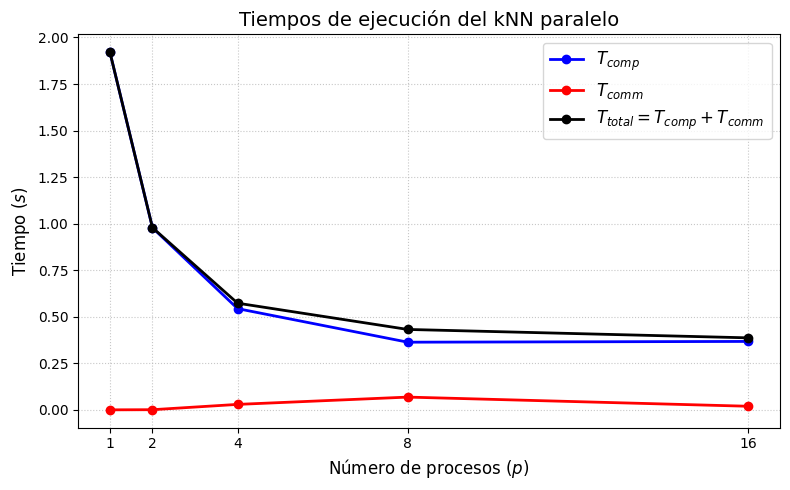

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['T_comp (s)'], marker='o', linestyle='-', color='b', label='$T_{comp}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_comm (s)'], marker='o', linestyle='-', color='r', label='$T_{comm}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_total (s)'], marker='o', linestyle='-', color='black', label='$T_{total} = T_{comp} + T_{comm}$', linewidth=2)

plt.title('Tiempos de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Cómputo $T_{comp}$ vs Comunicación $T_{comm}$

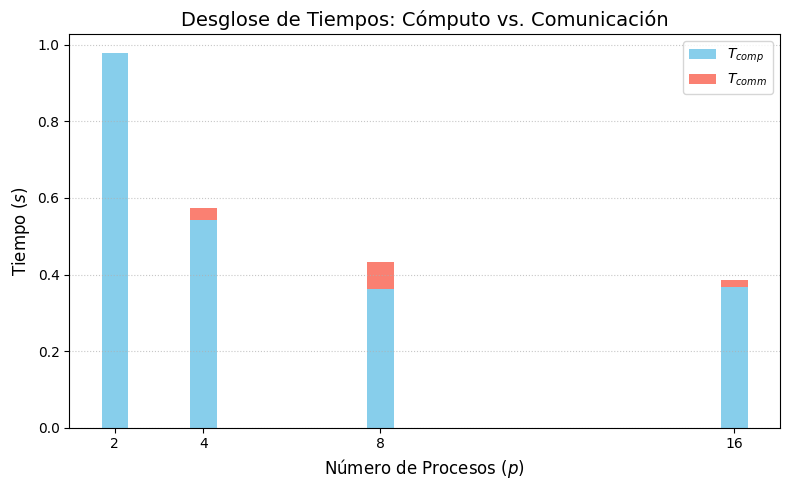

In [5]:
plt.figure(figsize=(8, 5))

df_mpi = df_100[df_100['Processes'] > 1]

plt.bar(df_mpi['Processes'], df_mpi['T_comp (s)'], color='skyblue', label='$T_{comp}$', width=0.6)
plt.bar(df_mpi['Processes'], df_mpi['T_comm (s)'], bottom=df_mpi['T_comp (s)'], color='salmon', label='$T_{comm}$', width=0.6)

plt.title('Desglose de Tiempos: Cómputo vs. Comunicación', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.xticks(df_mpi['Processes'])
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Accuracy del kNN paralelo

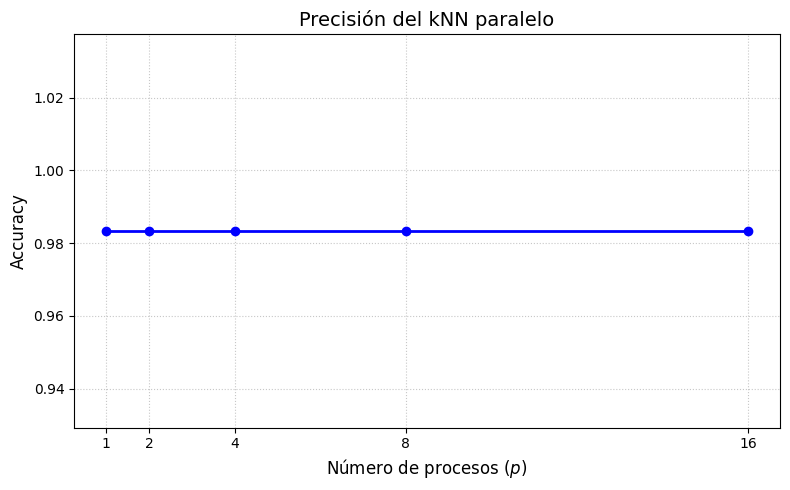

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Accuracy'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Precisión del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Cálculo del Speedup $S = T_s / T_p$

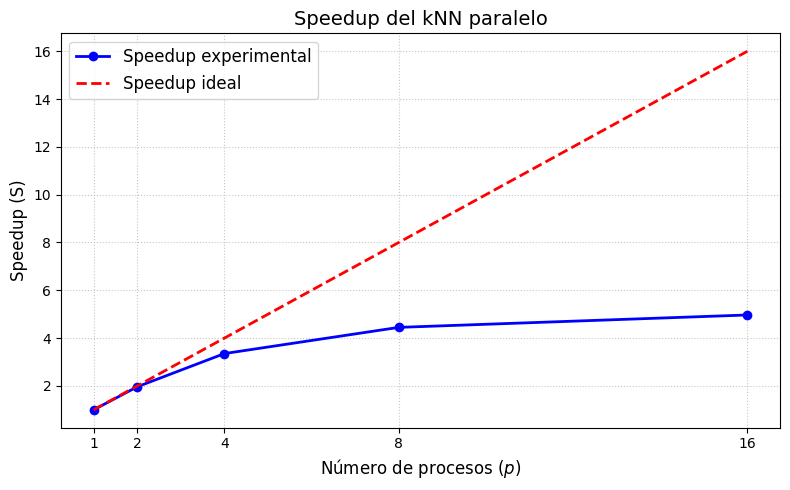

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Speedup'], marker='o', linestyle='-', color='b', label='Speedup experimental', linewidth=2)
plt.plot(df_100['Processes'], df_100['Processes'], marker='', linestyle='--', color='r', label='Speedup ideal', linewidth=2)

plt.title('Speedup del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Speedup (S)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### FLOP/s de ejecución del kNN

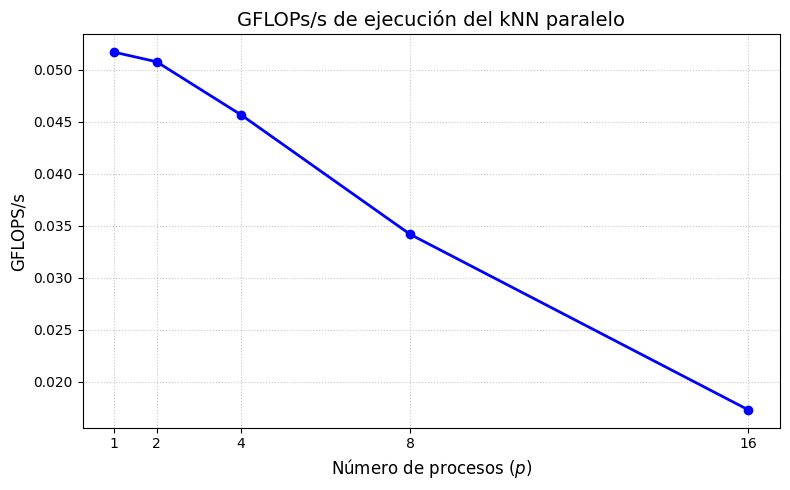

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['GFLOP/s'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('GFLOPs/s de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('GFLOPS/s', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Eficiencia del kNN paralelo

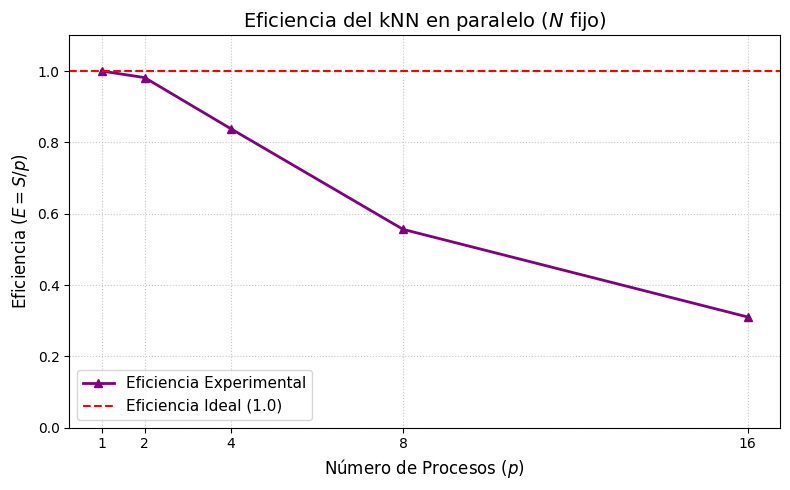

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Efficiency'], marker='^', linestyle='-', color='purple', label='Eficiencia Experimental', linewidth=2)
plt.axhline(y=1.0, color='r', linestyle='--', label='Eficiencia Ideal (1.0)')

plt.title('Eficiencia del kNN en paralelo ($N$ fijo)', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Eficiencia ($E = S / p$)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

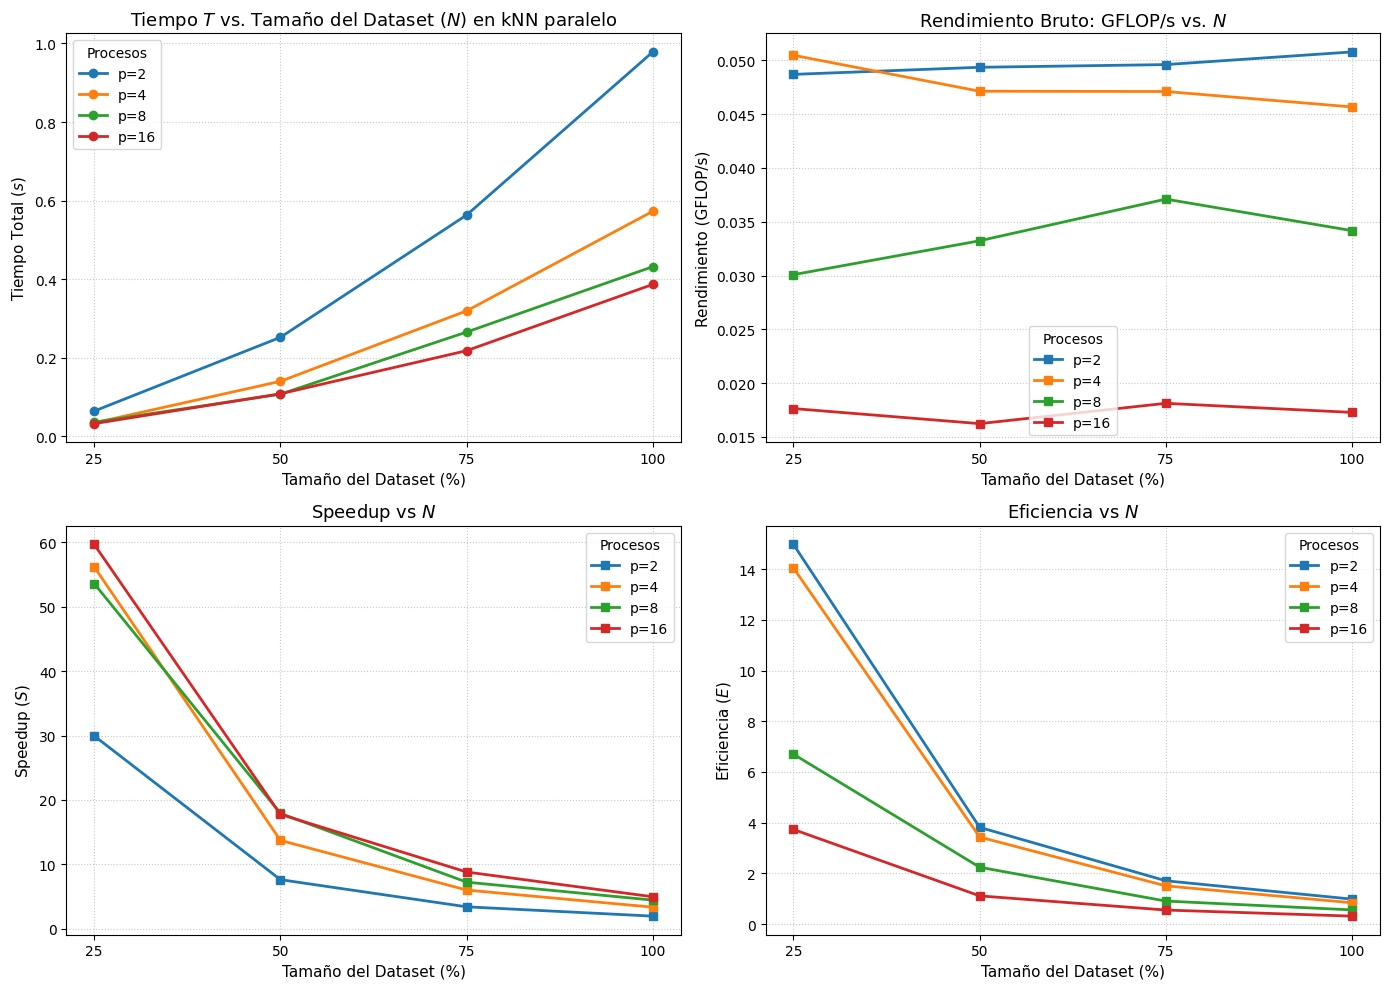

In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

df_mpi_np = df[df['Processes'] > 1]

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    ax1.plot(df_p['Subset_%'], df_p['T_total (s)'], marker='o', linewidth=2, label=f'p={p}')
    
ax1.set_title('Tiempo $T$ vs. Tamaño del Dataset ($N$) en kNN paralelo', fontsize=13)
ax1.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax1.set_ylabel('Tiempo Total ($s$)', fontsize=11)
ax1.set_xticks([25, 50, 75, 100])
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(title='Procesos')

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    ax2.plot(df_p['Subset_%'], df_p['GFLOP/s'], marker='s', linewidth=2, label=f'p={p}')
    
ax2.set_title('Rendimiento Bruto: GFLOP/s vs. $N$', fontsize=13)
ax2.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax2.set_ylabel('Rendimiento (GFLOP/s)', fontsize=11)
ax2.set_xticks([25, 50, 75, 100])
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(title='Procesos')

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    ax3.plot(df_p['Subset_%'], df_p['Speedup'], marker='s', linewidth=2, label=f'p={p}')
    
ax3.set_title('Speedup vs $N$', fontsize=13)
ax3.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax3.set_ylabel('Speedup ($S$)', fontsize=11)
ax3.set_xticks([25, 50, 75, 100])
ax3.grid(True, linestyle=':', alpha=0.7)
ax3.legend(title='Procesos')

for p in sorted(df_mpi_np['Processes'].unique()):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    ax4.plot(df_p['Subset_%'], df_p['Efficiency'], marker='s', linewidth=2, label=f'p={p}')
    
ax4.set_title('Eficiencia vs $N$', fontsize=13)
ax4.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax4.set_ylabel('Eficiencia ($E$)', fontsize=11)
ax4.set_xticks([25, 50, 75, 100])
ax4.grid(True, linestyle=':', alpha=0.7)
ax4.legend(title='Procesos')

plt.tight_layout()
plt.show()